In [1]:
import scanpy as sc 
slice_ids = ["2", "3", "4", "5", "6", "7", "9", "11", "17", "18", "19", "23", "24", "25", "26", "28", "33", "34", "36"]
def load_HMlymphNode(root_dir = '/maiziezhou_lab/Datasets/ST_datasets/humanMetastaticLymphNode/GSE251926_metastatic_lymph_node_3d.h5ad', section_id =  "1"):
    adataT = sc.read_h5ad(root_dir)
    section_id = int(section_id)  # Convert section_id to integer
    slice1 = adataT[adataT.obs['n_section'] == section_id]
    if 'gene_name' not in slice1.var.columns:
        slice1.var['gene_name'] = slice1.var_names
    slice1.obs['original_clusters'] = slice1.obs['annotation']
    slice1.obs['batch'] = section_id
    return slice1
section_ids = [4, 10]
st_data = load_HMlymphNode(section_id = slice_ids[10])

/tmp/ipykernel_372241/2367305920.py:8: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  slice1.var['gene_name'] = slice1.var_names


In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

tab20 = plt.get_cmap("tab20").colors
colors = [mcolors.rgb2hex(c) for c in tab20[:15]]
cell_types = [
    "Fibroblasts",
    "Tumor",
    "High_Endothelial_Venules",
    "M1_macrophages",
    "CAF",
    "Plasma_IgG",
    "unknown",
    "CAM",
    "Germinal_Center_Plasma_IgM_B_cell",
    "Plasma_IgA",
    "T_cell",
    "Tumor_Keratin_Pearl",
    "Macrophages",
    "Cytotoxic_IFN_signaling",
    "Cortex_CCL21",
]
color_map = dict(zip(cell_types, colors))
color_map

{'Fibroblasts': '#1f77b4',
 'Tumor': '#aec7e8',
 'High_Endothelial_Venules': '#ff7f0e',
 'M1_macrophages': '#ffbb78',
 'CAF': '#2ca02c',
 'Plasma_IgG': '#98df8a',
 'unknown': '#d62728',
 'CAM': '#ff9896',
 'Germinal_Center_Plasma_IgM_B_cell': '#9467bd',
 'Plasma_IgA': '#c5b0d5',
 'T_cell': '#8c564b',
 'Tumor_Keratin_Pearl': '#c49c94',
 'Macrophages': '#e377c2',
 'Cytotoxic_IFN_signaling': '#f7b6d2',
 'Cortex_CCL21': '#7f7f7f'}

In [3]:
import scanpy as sc 
st_data = sc.read_h5ad('/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/HumanLymph/totalData.h5ad')
st_data

AnnData object with n_obs × n_vars = 39167 × 28943
    obs: 'cell_ID_mask', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_reads', 'reads_per_counts', 'n_joined', 'exact_entropy', 'theoretical_entropy', 'exact_compression', 'theoretical_compression', 'n_counts', 'annotation', 'annotation_key', 'n_section', 'original_clusters', 'batch', 'Annotated', 'Predicted', 'scGPT reference mapping', 'nicheformer', 'RCTD', 'GraphST', 'scGPT linear probing', 'scGPT fine tuning', 'CARD', 'scANVI', 'Seurat', 'SingleR', 'SpatialDWLS', 'SPOTlight', 'SpatialID', 'TACCO', 'Tangram', 'DestVI', 'scCello_finetune', 'cell2location'
    uns: 'Annotated_colors', 'CARD_colors', 'GraphST_colors', 'Predicted_colors', 'RCTD_colors', 'SPOTlight_colors', 'Seurat_colors', 'SingleR_colors', 'SpatialDWLS_colors', 'SpatialID_colors', 'TACCO_colors', 'Tangram_colors', 'cell2location_colors', 'nicheformer_colors', 'scANVI_colors', 'scCello_finetune_colors', 'scGPT fine tuning_colors', 'scGPT li

In [4]:
niche = sc.read_h5ad('/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Nicheformer/partialFineTune/processed.h5ad')
niche.obs['pred_str']

38555    M1_macrophages
38556               CAF
38557               CAF
38558             Tumor
38559               CAF
              ...      
77717        Plasma_IgG
77718           unknown
77719           unknown
77720           unknown
77721           unknown
Name: pred_str, Length: 39167, dtype: category
Categories (15, object): ['CAF', 'CAM', 'Cortex_CCL21', 'Cytotoxic_IFN_signaling', ..., 'T_cell', 'Tumor', 'Tumor_Keratin_Pearl', 'unknown']

In [5]:
data = sc.read_h5ad('/maiziezhou_lab2/yuling/SToFM/fine_tuned_ddp/test_with_predictions.h5ad')
st_data.obs['Nicheformer_fine'] = niche.obs['pred_str'].values
st_data.obs['SToFM'] = data.obs['pred_original_clusters'] 

In [6]:
folders_dict = {
        'RCTD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/RCTD/HumanLymph_output',
        'Seurat': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Seurat/HumanLymph_output',
        'SingleR': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/SingleR/HumanLymph_output',
        'CARD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/CARD/HumanLymph_output',
        'Tangram': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Tangram/HumanLymph_output',
        'cell2location': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/cell2location/HumanLymph_output',
        'spatialDWLS': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialDWLS/HumanLymph_output',
        'spotlight': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spotlight/HumanLymph_output',
        'spatialID': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialID/HumanLymph_output/2024',
        'TACCO': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/tacco/HumanLymph_output',
        'DestVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/DestVI/HumanLymph_output',
        'scVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scVI/HumanLymph_output',
        'scGPT - (reference mapping)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scGPT/HumanLymph_reference_mapping',
        'scGPT - (partial fine tuning)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scGPT/HumanLymph',
        'scGPT - (linear probing)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scGPT/HumanLymph_linear_probing',
        'scCello - (linear probing)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scCello/linear_probing',
        'scCello - (partial fine tuning)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scCello/partial_fine_tune',
        'GraphST' : '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/GraphST/HumanLymph_output',
        'Nicheformer - (linear probing)' : '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Nicheformer/linearProbing',
        'Nicheformer - (partial fine tuning)' : '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Nicheformer/partialFineTune',
        'SToFM' : '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/SToFM/linearProbing',
    }

In [7]:
import os
import pandas as pd

def read_metrics_from_folders(folders_dict, filename="metrics_results.csv"):
    """
    Returns a DataFrame with:
    Method | accuracy | f1_macro
    """
    records = []

    for method, folder in folders_dict.items():
        csv_path = os.path.join(folder, filename)

        if not os.path.exists(csv_path):
            print(f"[WARNING] Missing metrics file for {method}: {csv_path}")
            continue

        df = pd.read_csv(csv_path)

        # assume one-row csv (your screenshot confirms this)
        row = df.iloc[0]

        records.append({
            "Method": method,
            "accuracy": row["accuracy"],
            "f1_macro": row["f1_macro"],
        })

    return pd.DataFrame(records)


metrics_df = read_metrics_from_folders(folders_dict)
metrics_df

,Method,accuracy,f1_macro
0,RCTD,0.475732,0.284495
1,Seurat,0.565629,0.342169
2,SingleR,0.536855,0.384512
3,CARD,0.540302,0.313153
4,Tangram,0.424541,0.147353
5,cell2location,0.534634,0.337758
6,spatialDWLS,0.492762,0.278031
7,spotlight,0.491230,0.266627
8,spatialID,0.643603,0.388381
9,TACCO,0.624633,0.340964


In [8]:
panel_to_method = {
    "scGPT (partial fine tuning)": "scGPT - (partial fine tuning)",
    "scGPT (reference mapping)": "scGPT - (reference mapping)",
    "scGPT (linear probing)": "scGPT - (linear probing)",
    "scCello (partial fine tuning)": "scCello - (partial fine tuning)",
    "scCello (linear probing)": "scCello - (linear probing)",
    "SToFM": "SToFM",
    "Seurat": "Seurat",
    "DestVI": "DestVI",
    "CARD": "CARD",
    "SingleR": "SingleR",
    "Cell2location": "cell2location",
    "SpatialDWLS": "spatialDWLS",
    "SPOTlight": "spotlight",
    "RCTD": "RCTD",
    "Tangram": "Tangram",
    "GraphST": "GraphST",
    "Spatial-ID": "spatialID",
    "TACCO": "TACCO",
    "Nicheformer (linear probing)": "Nicheformer - (linear probing)",
    "Nicheformer (partial fine tuning)": "Nicheformer - (partial fine tuning)",
    "scANVI": "scVI",
    # explicitly skipped
    "Annotated": None,
}
panel_metrics = []
panel_titles = [
     "Annotated",
     "scGPT (partial fine tuning)",
     "scANVI",
     "Spatial-ID",
      "scCello (partial fine tuning)",
     "TACCO",
    "scCello (linear probing)",
    "DestVI",
    "scGPT (reference mapping)",
    "Seurat",
     "Nicheformer (partial fine tuning)",
     "CARD",
     "SingleR",
     "Cell2location",
     "Nicheformer (linear probing)",
     "SpatialDWLS",
     "SPOTlight",
    "RCTD",
    "scGPT (linear probing)",
    "Tangram",
    "GraphST",
     "SToFM",
]
for title in panel_titles:
    method = panel_to_method.get(title)

    if method is None:
        continue  # skip Annotated

    row = metrics_df.loc[metrics_df["Method"] == method]

    if row.empty:
        print(f"[WARNING] No metrics found for panel '{title}' ({method})")
        continue

    panel_metrics.append({
        "panel_title": title,
        "accuracy": float(row["accuracy"]),
        "f1_macro": float(row["f1_macro"]),
    })

panel_metrics_df = pd.DataFrame(panel_metrics)
panel_metrics_df


/tmp/ipykernel_372241/3130586336.py:65: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "accuracy": float(row["accuracy"]),
/tmp/ipykernel_372241/3130586336.py:66: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "f1_macro": float(row["f1_macro"]),


,panel_title,accuracy,f1_macro
0,scGPT (partial fine tuning),0.672199,0.333661
1,scANVI,0.654811,0.460643
2,Spatial-ID,0.643603,0.388381
3,scCello (partial fine tuning),0.632165,0.389988
4,TACCO,0.624633,0.340964
5,scCello (linear probing),0.584931,0.341140
6,DestVI,0.573289,0.266348
7,scGPT (reference mapping),0.569765,0.292095
8,Seurat,0.565629,0.342169
9,Nicheformer (partial fine tuning),0.560089,0.358086


In [9]:
def format_panel_title(title, acc, f1):
    return f"{title}\nAcc={acc:.3f}, Macro F1={f1:.3f}"
title_map = {
        row["panel_title"]: format_panel_title(
            row["panel_title"], row["accuracy"], row["f1_macro"]
        )
        for _, row in panel_metrics_df.iterrows()
    }
title_map

{'scGPT (partial fine tuning)': 'scGPT (partial fine tuning)\nAcc=0.672, Macro F1=0.334',
 'scANVI': 'scANVI\nAcc=0.655, Macro F1=0.461',
 'Spatial-ID': 'Spatial-ID\nAcc=0.644, Macro F1=0.388',
 'scCello (partial fine tuning)': 'scCello (partial fine tuning)\nAcc=0.632, Macro F1=0.390',
 'TACCO': 'TACCO\nAcc=0.625, Macro F1=0.341',
 'scCello (linear probing)': 'scCello (linear probing)\nAcc=0.585, Macro F1=0.341',
 'DestVI': 'DestVI\nAcc=0.573, Macro F1=0.266',
 'scGPT (reference mapping)': 'scGPT (reference mapping)\nAcc=0.570, Macro F1=0.292',
 'Seurat': 'Seurat\nAcc=0.566, Macro F1=0.342',
 'Nicheformer (partial fine tuning)': 'Nicheformer (partial fine tuning)\nAcc=0.560, Macro F1=0.358',
 'CARD': 'CARD\nAcc=0.540, Macro F1=0.313',
 'SingleR': 'SingleR\nAcc=0.537, Macro F1=0.385',
 'Cell2location': 'Cell2location\nAcc=0.535, Macro F1=0.338',
 'Nicheformer (linear probing)': 'Nicheformer (linear probing)\nAcc=0.524, Macro F1=0.202',
 'SpatialDWLS': 'SpatialDWLS\nAcc=0.493, Macro F1=

In [10]:
color_map = {
    'Fibroblasts': '#1f4e79',
 'Tumor': '#d62728',
 'High_Endothelial_Venules': '#ff7f0e',
 'M1_macrophages': '#ffbb78',
 'CAF': '#6a3d9a',
 'Plasma_IgG': '#98df8a',
 'unknown': '#aec7e8',
 'CAM': '#ff9896',
 'Germinal_Center_Plasma_IgM_B_cell': '#1f77b4',
 'Plasma_IgA': '#c5b0d5',
 'T_cell': '#8c564b',
 'Tumor_Keratin_Pearl': '#c49c94',
 'Macrophages': '#e377c2',
 'Cytotoxic_IFN_signaling': '#f7b6d2',
 'Cortex_CCL21': '#7f7f7f'
}

# Adjust color 

'Fibroblasts': '#9467bd',
 'Tumor': '#d62728',
 'High_Endothelial_Venules': '#ff7f0e',
 'M1_macrophages': '#ffbb78',
 'CAF': '#2ca02c',
 'Plasma_IgG': '#98df8a',
 'unknown': '#aec7e8',
 'CAM': '#ff9896',
 'Germinal_Center_Plasma_IgM_B_cell': '#9467bd', '#1f77b4',
 'Plasma_IgA': '#c5b0d5',
 'T_cell': '#8c564b',
 'Tumor_Keratin_Pearl': '#c49c94',
 'Macrophages': '#e377c2',
 'Cytotoxic_IFN_signaling': '#f7b6d2',
 'Cortex_CCL21': '#7f7f7f'

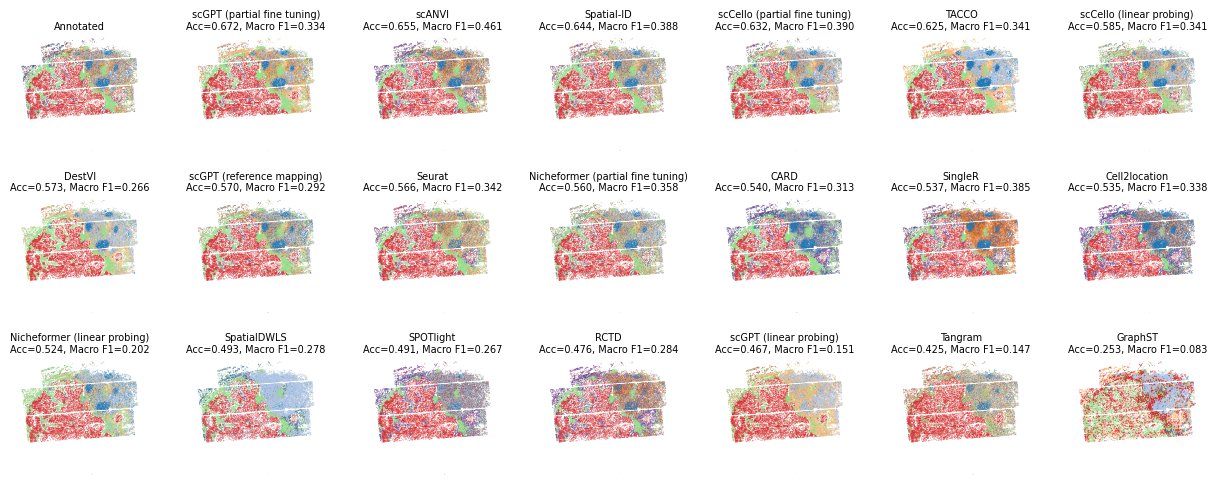

In [11]:
import matplotlib.pyplot as plt
def format_panel_title(title, acc, f1):
    return f"{title}\nAcc={acc:.3f} | F1={f1:.3f}"
methods = [
    'Annotated',
     "scGPT fine tuning",
     "scANVI",
     "SpatialID",
     "scCello_finetune",
     "TACCO",
    "Predicted",
    "DestVI",
    "scGPT reference mapping",
    "Seurat",
    "Nicheformer_fine",
     "CARD",
     "SingleR",
     "cell2location",
     "nicheformer",
     "SpatialDWLS",
     "SPOTlight",
    "RCTD",
    "scGPT linear probing",
    "Tangram",
    "GraphST",
    "SToFM"
]
fig, axes = plt.subplots(3, 7, figsize=(12.5, 5))
axes = axes.flatten()
for ax, method, title in zip(axes, methods, panel_titles):
    sc.pl.spatial(
        st_data,
        color=method,
        spot_size= 60,
        palette=color_map,
        title=title,
        ax=ax,
        show=False
    )
    if title == 'Annotated':
        ax.set_title('Annotated', fontsize=7, pad=2)

    #ax.set_title(title, fontsize=8, pad=2)
        ax.set_axis_off()
        ax.get_legend().remove() if ax.get_legend() else None
    else:
    # later:
        ax.set_title(title_map[title], fontsize=7, pad=2)

        #ax.set_title(title, fontsize=8, pad=2)
        ax.set_axis_off()
        ax.get_legend().remove() if ax.get_legend() else None

plt.tight_layout()
fig.savefig(
    "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/HumanLymph/spatial_panels_0222.pdf",
    bbox_inches="tight",
    format="pdf"
)

plt.show()


# select Tumor microenvironment for visualization 

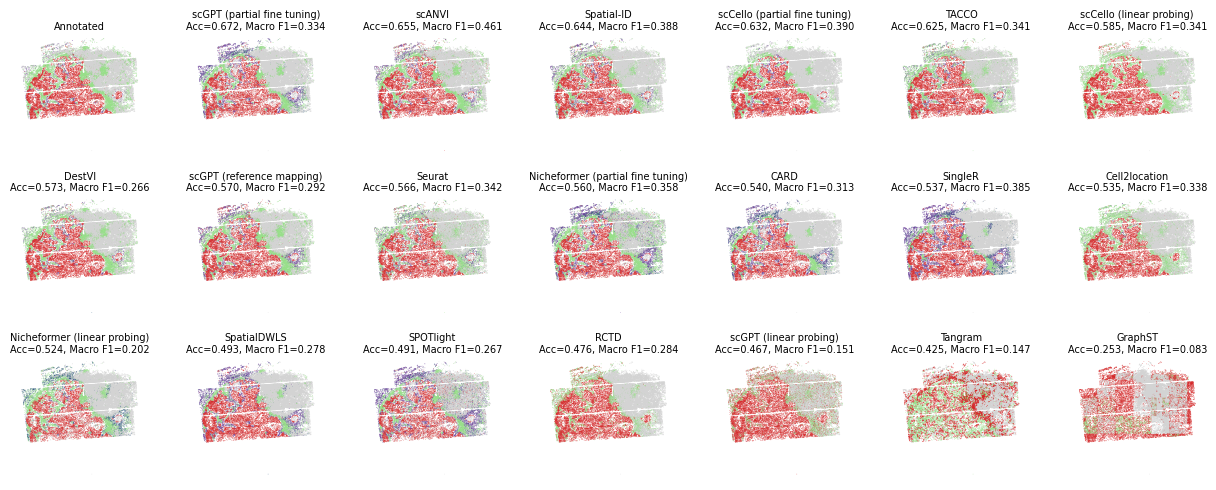

In [12]:
import numpy as np
import matplotlib.pyplot as plt
methods = [
     #"Annotated",
     "scGPT fine tuning",
     "scANVI",
     "SpatialID",
     "scCello_finetune",
     "TACCO",
    "Predicted",
    "DestVI",
    "scGPT reference mapping",
    "Seurat",
    "Nicheformer_fine",
     "CARD",
     "SingleR",
     "cell2location",
     "nicheformer",
     "SpatialDWLS",
     "SPOTlight",
    "RCTD",
    "scGPT linear probing",
    "Tangram",
    "GraphST",
    "SToFM"
]
TARGET_CTS = ['Fibroblasts','CAF','Plasma_IgG','Tumor']
GREY_COLOR = "#D3D3D3"

fig, axes = plt.subplots(3, 7, figsize=(12.5, 5))
axes = axes.flatten()

for ax, method, title in zip(axes, methods, panel_titles):

    tmp_col = f"{method}_highlight"

    # ---------- build palette ----------
    highlight_palette = {ct: color_map[ct] for ct in TARGET_CTS}
    highlight_palette["Other"] = GREY_COLOR

    # ---------- assign temporary labels ----------
    st_data.obs[tmp_col] = np.where(
        st_data.obs[method].isin(TARGET_CTS),
        st_data.obs[method],   # keep original label
        "Other"
    )

    # ---------- plot ----------
    sc.pl.spatial(
        st_data,
        color=tmp_col,
        spot_size=60,
        palette=highlight_palette,
        ax=ax,
        show=False
    )

    # ---------- title & cosmetics ----------
    if title == 'Annotated':
        ax.set_title('Annotated', fontsize=7, pad=2)
    else:
        ax.set_title(title_map[title], fontsize=7, pad=2)

    ax.set_axis_off()
    if ax.get_legend():
        ax.get_legend().remove()

    # ---------- cleanup ----------
    del st_data.obs[tmp_col]

plt.tight_layout()
fig.savefig(
    "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/HumanLymph/spatial_panels_multiCT0220.pdf",
    bbox_inches="tight",
    format="pdf"
)
plt.show()

